In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.5 MB/s eta 0:00:00


In [3]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph
)

from reportlab.lib.styles import getSampleStyleSheet

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding='ISO-8859-1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [10]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [11]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [12]:
print("Total Sales:", df["Sales"].sum())

print("Total Profit:", df["Profit"].sum())

print("Total Orders:", df["Order ID"].nunique())

print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


In [13]:
report = f"""
AI Business Intelligence Platform

Dataset Summary

Rows: {df.shape[0]}

Columns: {df.shape[1]}

Total Sales: {df['Sales'].sum():.2f}

Total Profit: {df['Profit'].sum():.2f}

Total Orders: {df['Order ID'].nunique()}

Total Customers: {df['Customer ID'].nunique()}
"""

print(report)


AI Business Intelligence Platform

Dataset Summary

Rows: 9994

Columns: 21

Total Sales: 2297200.86

Total Profit: 286397.02

Total Orders: 5009

Total Customers: 793



In [14]:
with open(
    "dataset_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("Dataset Report Saved")

Dataset Report Saved


In [15]:
missing_values = df.isnull().sum()

missing_report = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_report

,Column,Missing Values
0,Row ID,0
1,Order ID,0
2,Order Date,0
3,Ship Date,0
4,Ship Mode,0
5,Customer ID,0
6,Customer Name,0
7,Segment,0
8,Country,0
9,City,0


In [16]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [17]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Records:",
    duplicates
)

Duplicate Records: 0


In [18]:
df = df.drop_duplicates()

print(
    "New Shape:",
    df.shape
)

New Shape: (9994, 21)


In [19]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_report

,Column,Data Type
0,Row ID,int64
1,Order ID,object
2,Order Date,object
3,Ship Date,object
4,Ship Mode,object
5,Customer ID,object
6,Customer Name,object
7,Segment,object
8,Country,object
9,City,object


In [20]:
unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique Values":
    [df[col].nunique()
     for col in df.columns]
})

unique_report

,Column,Unique Values
0,Row ID,9994
1,Order ID,5009
2,Order Date,1237
3,Ship Date,1334
4,Ship Mode,4
5,Customer ID,793
6,Customer Name,793
7,Segment,3
8,Country,1
9,City,531


In [21]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
)

numeric_cols.head()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164


In [22]:
for col in numeric_cols.columns:

    q1 = df[col].quantile(0.25)

    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower)
        |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)} outliers"
    )

Row ID: 0 outliers
Postal Code: 0 outliers
Sales: 1167 outliers
Quantity: 170 outliers
Discount: 856 outliers
Profit: 1881 outliers


In [23]:
total_cells = (
    df.shape[0]
    *
    df.shape[1]
)

missing_cells = (
    df.isnull().sum().sum()
)

quality_score = (
    (total_cells - missing_cells)
    /
    total_cells
) * 100

print(
    f"Data Quality Score: "
    f"{quality_score:.2f}%"
)

Data Quality Score: 100.00%


In [24]:
quality_report = f"""
AI Business Intelligence Platform

DATA QUALITY REPORT

Rows:
{df.shape[0]}

Columns:
{df.shape[1]}

Missing Values:
{df.isnull().sum().sum()}

Duplicate Records:
{duplicates}

Data Quality Score:
{quality_score:.2f}%
"""

print(quality_report)


AI Business Intelligence Platform

DATA QUALITY REPORT

Rows:
9994

Columns:
21

Missing Values:
0

Duplicate Records:
0

Data Quality Score:
100.00%



In [25]:
with open(
    "data_quality_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        quality_report
    )

print(
    "Data Quality Report Saved"
)

Data Quality Report Saved


In [26]:
df.to_csv(
    "cleaned_superstore.csv",
    index=False
)

print(
    "Clean Dataset Saved"
)

Clean Dataset Saved


In [27]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


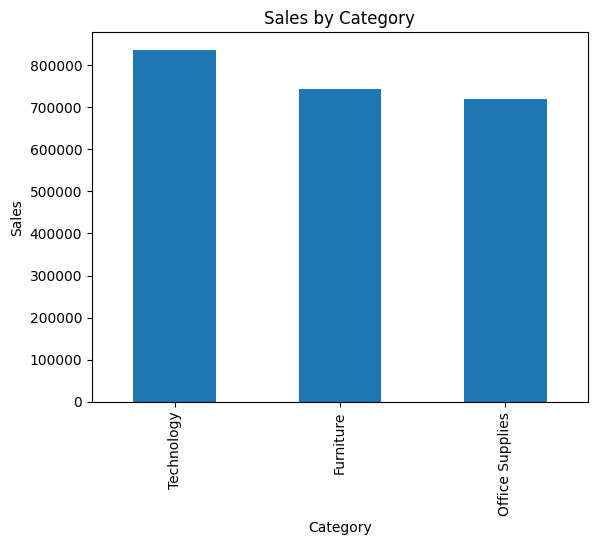

In [28]:
sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [29]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


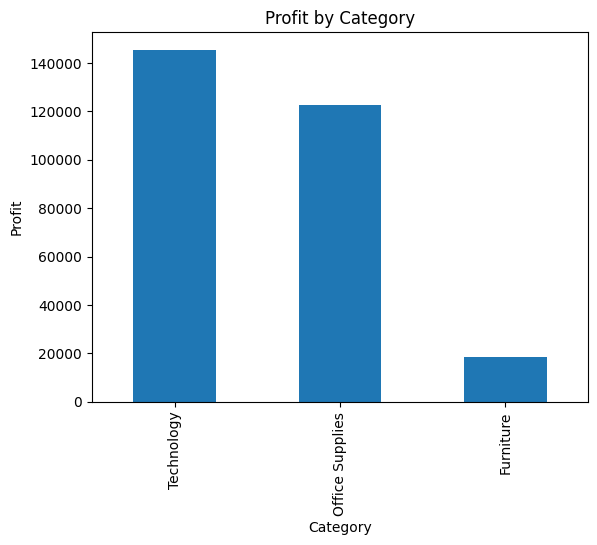

In [30]:
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [31]:
sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_region)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


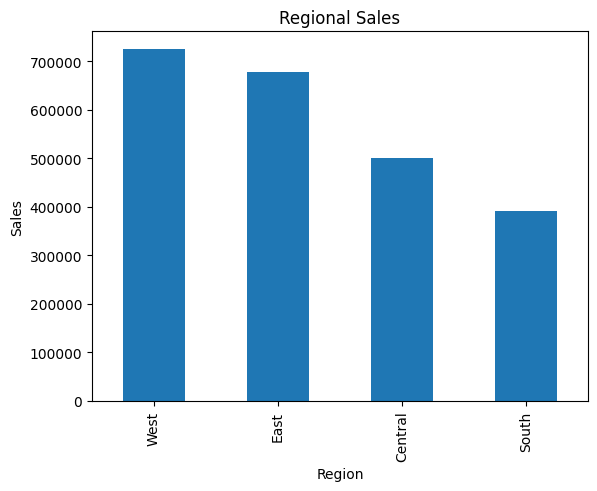

In [32]:
sales_region.plot(kind="bar")

plt.title("Regional Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [33]:
profit_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_region)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


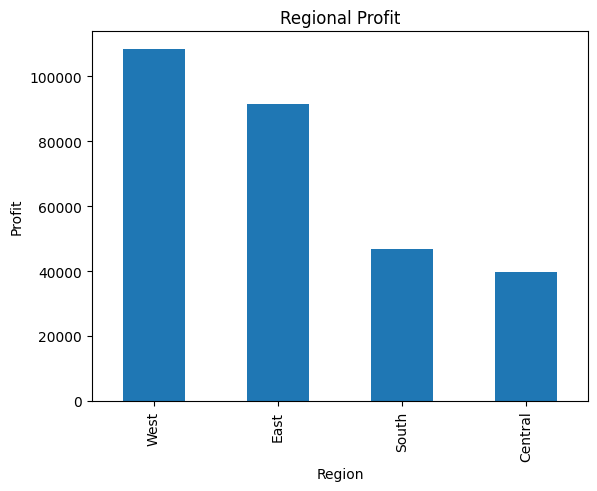

In [34]:
profit_region.plot(kind="bar")

plt.title("Regional Profit")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [35]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [36]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [37]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


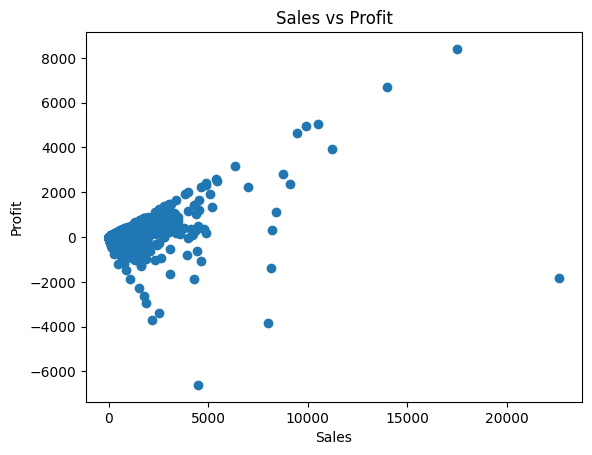

In [38]:
plt.scatter(
    df["Sales"],
    df["Profit"]
)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

In [39]:
top_category = sales_by_category.idxmax()

top_region = sales_region.idxmax()

top_customer = top_customers.index[0]

insights = f"""
BUSINESS INSIGHTS

Top Sales Category:
{top_category}

Top Region:
{top_region}

Top Customer:
{top_customer}

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}
"""

print(insights)


BUSINESS INSIGHTS

Top Sales Category:
Technology

Top Region:
West

Top Customer:
Sean Miller

Total Sales:
2297200.86

Total Profit:
286397.02



In [40]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

In [41]:
df["Year"] = (
    df["Order Date"]
    .dt.year
)

df["Month"] = (
    df["Order Date"]
    .dt.month
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


In [42]:
monthly_sales = (
    df.groupby(
        ["Year", "Month"]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


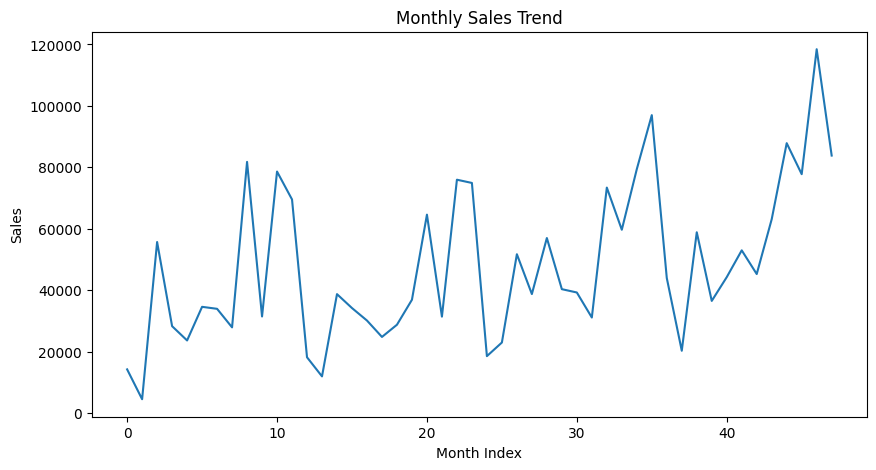

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Sales"]
)

plt.title(
    "Monthly Sales Trend"
)

plt.xlabel("Month Index")

plt.ylabel("Sales")

plt.show()

In [44]:
monthly_profit = (
    df.groupby(
        ["Year", "Month"]
    )["Profit"]
    .sum()
    .reset_index()
)

monthly_profit.head()

,Year,Month,Profit
0,2014,1,2450.1907
1,2014,2,862.3084
2,2014,3,498.7299
3,2014,4,3488.8352
4,2014,5,2738.7096


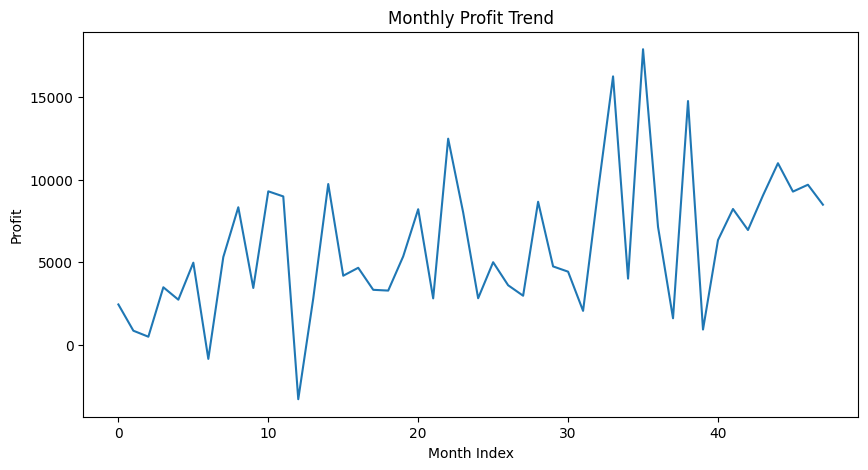

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_profit["Profit"]
)

plt.title(
    "Monthly Profit Trend"
)

plt.xlabel("Month Index")

plt.ylabel("Profit")

plt.show()

In [46]:
top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_states)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


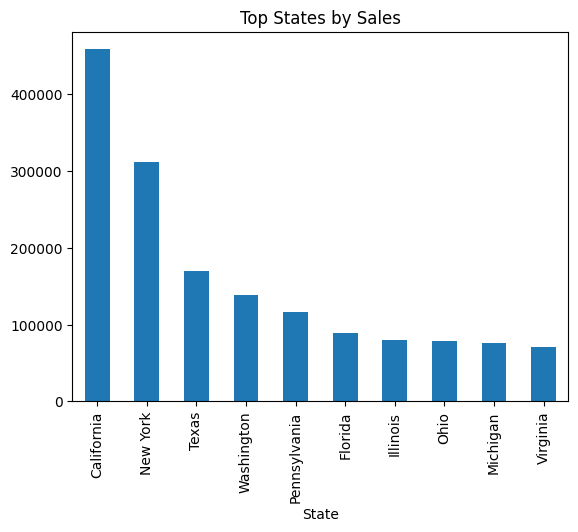

In [47]:
top_states.plot(
    kind="bar"
)

plt.title(
    "Top States by Sales"
)

plt.show()

In [48]:
total_sales = (
    df["Sales"].sum()
)

total_profit = (
    df["Profit"].sum()
)

total_orders = (
    df["Order ID"]
    .nunique()
)

avg_order_value = (
    total_sales
    /
    total_orders
)

print(
    f"Total Sales: {total_sales:.2f}"
)

print(
    f"Total Profit: {total_profit:.2f}"
)

print(
    f"Total Orders: {total_orders}"
)

print(
    f"Average Order Value: {avg_order_value:.2f}"
)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Average Order Value: 458.61


In [49]:
best_category = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .idxmax()
)

print(
    "Best Category:",
    best_category
)

Best Category: Technology


In [50]:
best_region = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .idxmax()
)

print(
    "Best Region:",
    best_region
)

Best Region: West


In [51]:
executive_summary = f"""
EXECUTIVE SUMMARY

Total Sales:
{total_sales:.2f}

Total Profit:
{total_profit:.2f}

Total Orders:
{total_orders}

Average Order Value:
{avg_order_value:.2f}

Best Performing Category:
{best_category}

Best Performing Region:
{best_region}
"""

print(
    executive_summary
)


EXECUTIVE SUMMARY

Total Sales:
2297200.86

Total Profit:
286397.02

Total Orders:
5009

Average Order Value:
458.61

Best Performing Category:
Technology

Best Performing Region:
West



In [52]:
with open(
    "executive_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        executive_summary
    )

print(
    "Executive Summary Saved"
)

Executive Summary Saved


In [53]:
!pip install -q google-generativeai

In [54]:
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [60]:
API_KEY = "AQ.Ab8RN6LiOM5y1o_TXUBDMsmi50-xXrpqxq8DfnEhxPo858b6PA"

genai.configure(api_key=API_KEY)

In [61]:
model = genai.GenerativeModel(
    "gemini-2.5-flash"
)

print("Gemini Connected Successfully!")

Gemini Connected Successfully!


In [62]:
dataset_summary = f"""
Business Dataset Summary

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}

Total Orders:
{df['Order ID'].nunique()}

Total Customers:
{df['Customer ID'].nunique()}

Top Category:
{best_category}

Top Region:
{best_region}
"""

print(dataset_summary)


Business Dataset Summary

Total Sales:
2297200.86

Total Profit:
286397.02

Total Orders:
5009

Total Customers:
793

Top Category:
Technology

Top Region:
West



In [63]:
prompt = f"""
You are an experienced Business Intelligence Analyst.

Based on the following dataset summary, provide:

1. Executive Summary
2. Key Business Insights
3. Business Risks
4. Opportunities
5. Recommendations
6. Action Plan

Dataset Summary:

{dataset_summary}
"""

In [64]:
response = model.generate_content(prompt)

ai_insights = response.text

print(ai_insights)

Here is a comprehensive business intelligence report based on the provided dataset summary:

---

## Business Performance Analysis Report

**Date:** October 26, 2023
**Prepared for:** Executive Leadership Team

---

### 1. Executive Summary

The business demonstrates a strong overall performance, with **total sales exceeding $2.29 million** and generating a **healthy total profit of over $286K**. This translates to a **profit margin of approximately 12.47%**, indicating efficient operations. The company serves an active customer base of 793 individuals, fulfilling over 5,000 orders. **Technology** products are the primary revenue drivers, and the **West** region stands out as the highest-performing geographical market. While current performance is robust, the concentration of success in a single category and region presents both opportunities for targeted growth and potential risks requiring strategic diversification.

---

### 2. Key Business Insights

*   **Robust Financial Performan

In [65]:
with open(
    "ai_business_insights.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(ai_insights)

print("AI Insights Saved")

AI Insights Saved


In [66]:
question = input("Ask a business question: ")

Ask a business question: what is the ROI ?


In [67]:
qa_prompt = f"""
Dataset Summary:

{dataset_summary}

Question:

{question}

Answer like a Senior Business Analyst.
"""

answer = model.generate_content(
    qa_prompt
)

print(answer.text)

As a Senior Business Analyst, my primary objective is to provide precise and actionable insights.

Based on the dataset provided:

*   **Total Sales:** 2,297,200.86
*   **Total Profit:** 286,397.02

**To calculate a precise Return on Investment (ROI), we require the "Cost of Investment" or the "Total Capital Invested" over the period.** The current dataset provides profit and sales figures, but it lacks this crucial denominator for the ROI formula.

**ROI Formula:**
ROI = (Net Profit / Cost of Investment) * 100%

**Without the "Cost of Investment" figure, a direct and accurate ROI calculation is not possible.**

**What we *can* immediately assess from the provided data is the Profit Margin on Sales:**

Profit Margin = (Total Profit / Total Sales) * 100%
Profit Margin = (286,397.02 / 2,297,200.86) * 100%
**Profit Margin ≈ 12.47%**

This indicates that, for every dollar in sales, approximately 12.47 cents is retained as profit. While this is a healthy indicator of operational efficiency 

In [68]:
swot_prompt = f"""
Perform a SWOT Analysis for this business.

Dataset Summary:

{dataset_summary}
"""

swot = model.generate_content(
    swot_prompt
)

print(swot.text)

Here's a SWOT analysis for the business based on the provided dataset summary:

---

## SWOT Analysis: Business Dataset Summary

**Strengths (Internal - Positive Attributes)**

1.  **Strong Revenue Generation:** With total sales exceeding $2.2 million, the business has a substantial market presence and generates significant income.
2.  **Healthy Profitability:** A total profit of over $286,000 indicates a financially sound operation with a decent profit margin (~12.5% of sales), suggesting efficient cost management and effective pricing.
3.  **High Customer Engagement & Loyalty:** 5009 orders from 793 customers implies an average of over 6 orders per customer, indicating strong repeat business and customer loyalty rather than just one-off purchases.
4.  **Market Leadership in Technology Category:** "Technology" being the top category suggests expertise, strong product offerings, and a established market position within that niche.
5.  **Established Regional Presence:** "West" being the

In [69]:
with open(
    "swot_analysis.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(swot.text)

print("SWOT Analysis Saved")

SWOT Analysis Saved


In [70]:
report_prompt = f"""
You are a Senior Business Intelligence Consultant.

Generate a professional Executive Business Report.

Include:

1. Executive Summary

2. Sales Performance

3. Profit Analysis

4. Customer Analysis

5. Regional Performance

6. Business Risks

7. Growth Opportunities

8. Recommendations

Dataset Summary:

{dataset_summary}
"""

In [72]:
report_response = model.generate_content(
    report_prompt
)

executive_report = report_response.text

print(executive_report)

## Executive Business Report: QX 2024 Performance Review

**Report Date:** October 26, 2023
**Prepared For:** Executive Leadership Team
**Prepared By:** Senior Business Intelligence Consultant

---

### 1. Executive Summary

This report provides a comprehensive review of our business performance for the period, highlighting key financial and operational metrics. We achieved robust overall sales totaling **$2,297,200.86** with a healthy **$286,397.02** in profit, reflecting a commendable profit margin of approximately **12.47%**. Our operations handled **5,009 orders** from **793 unique customers**, indicating a valuable and engaged customer base. The **Technology** category and the **West** region emerged as our primary growth engines and profit drivers. While performance is strong, strategic diversification and optimization opportunities exist to mitigate concentration risks and sustain future growth.

---

### 2. Sales Performance

Our sales performance demonstrates strong market tra

In [73]:
with open(
    "executive_business_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(executive_report)

print("Executive Report Saved")

Executive Report Saved


In [74]:
styles = getSampleStyleSheet()

doc = SimpleDocTemplate(
    "executive_business_report.pdf"
)

story = []

story.append(
    Paragraph(
        executive_report.replace("\n", "<br/>"),
        styles["BodyText"]
    )
)

doc.build(story)

print("PDF Report Created")

PDF Report Created


In [75]:
kpi_prompt = f"""
Generate a KPI Report.

Include:

- Total Sales
- Total Profit
- Average Order Value
- Best Category
- Best Region
- Business Health Score

Dataset Summary:

{dataset_summary}
"""

In [76]:
kpi_response = model.generate_content(
    kpi_prompt
)

kpi_report = kpi_response.text

print(kpi_report)

Okay, here is a KPI Report generated from your provided dataset summary.

---

## KPI Report - Business Performance Overview

**Date:** October 26, 2023

---

### Executive Summary

This report provides a snapshot of key business performance indicators. The business demonstrates strong overall sales and a healthy Average Order Value. Technology products and the West region are identified as the top performers. While the business health is good, continuous monitoring of profit margins will be beneficial for sustained growth.

---

### Key Performance Indicators (KPIs)

Here are the detailed insights:

1.  **Total Sales**
    *   **Value:** **$2,297,200.86**
    *   **Insight:** Represents the total revenue generated by the business. This is a robust sales figure, indicating strong market activity.

2.  **Total Profit**
    *   **Value:** **$286,397.02**
    *   **Insight:** Reflects the net earnings after all expenses. This profit figure supports the overall health of the business.

3. 

In [77]:
with open(
    "kpi_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(kpi_report)

print("KPI Report Saved")

KPI Report Saved


In [78]:
board_prompt = f"""
Prepare a one-page Board Meeting Summary.

Include:

Business Performance

Major Risks

Growth Areas

Future Strategy

Dataset Summary:

{dataset_summary}
"""

In [79]:
board_response = model.generate_content(
    board_prompt
)

board_summary = board_response.text

print(board_summary)

## Board Meeting Summary: Q[X] Performance Review

**Date:** October 26, 2023

**Prepared For:** The Board of Directors

---

**Overview:**
This summary provides a concise overview of our recent business performance, key risks, identified growth opportunities, and the strategic direction for the upcoming period. We continue to demonstrate strong core performance driven by our strengths in key areas, while proactively addressing challenges and positioning for future expansion.

---

### 1. Business Performance

Our financial and operational results for the period demonstrate robust performance, indicating a strong market position and effective execution.

*   **Total Sales:** **$2,297,200.86**
    *   Achieved a significant revenue milestone, reflecting strong demand for our products/services.
*   **Total Profit:** **$286,397.02**
    *   Maintained a healthy profit margin of approximately 12.47%, underscoring efficient operations and effective pricing strategies.
*   **Total Orders:** 

In [80]:
with open(
    "board_meeting_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(board_summary)

print("Board Summary Saved")

Board Summary Saved


In [81]:
dataset_context = f"""
Business Dataset Summary

Rows:
{df.shape[0]}

Columns:
{list(df.columns)}

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}

Top Categories

{sales_by_category}

Top Regions

{sales_region}

Top Customers

{top_customers}

Segment Sales

{segment_sales}
"""

print(dataset_context)


Business Dataset Summary

Rows:
9994

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month']

Total Sales:
2297200.86

Total Profit:
286397.02

Top Categories

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Top Regions

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Top Customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant 

In [82]:
def chat_with_dataset(question):

    prompt = f"""
You are a Senior Business Intelligence Analyst.

Dataset Information:

{dataset_context}

User Question:

{question}

Answer professionally.

If appropriate:

• Explain reasoning

• Give business insight

• Suggest actions
"""

    response = model.generate_content(prompt)

    return response.text

In [83]:
question = "Which region contributes the highest revenue?"

answer = chat_with_dataset(question)

print(answer)

Based on the provided dataset summary, the **West** region contributes the highest revenue.

**Reasoning:**
The "Top Regions" data clearly shows the sales figures for each region. The West region leads with total sales of **$725,457.82**, which is the highest among all listed regions.

**Business Insight:**
The West region is currently your strongest revenue driver. This indicates a highly effective market presence, successful sales strategies, or a favorable market environment within this region. Identifying your top-performing regions is crucial for understanding where your business is most successful and where resources are most effectively utilized.

**Suggested Actions:**
1.  **Deep Dive into Success Factors:** Conduct further analysis to understand the specific drivers behind the West region's high performance. This could include examining popular products/categories, effective sales channels, successful marketing campaigns, customer demographics, or operational efficiencies uniq

In [84]:
while True:

    user_question = input("Ask a business question (type exit to stop): ")

    if user_question.lower() == "exit":
        break

    print("\nAI Answer\n")

    print(chat_with_dataset(user_question))

    print("\n")

Ask a business question (type exit to stop): Which region contributes the highest revenue?

AI Answer

The region that contributes the highest revenue is the **West** region.

**Reasoning:**
Based on the provided dataset summary for "Top Regions", the sales figures are as follows:
*   **West:** \$725,457.82
*   East: \$678,781.24
*   Central: \$501,239.89
*   South: \$391,721.90

The West region clearly leads with the highest sales volume.

**Business Insight:**
The West region is currently our strongest market in terms of revenue generation, contributing a significant portion of the total sales. This indicates a robust customer base, effective sales strategies, or strong market demand within this geographical area.

**Suggested Actions:**
1.  **Analyze and Replicate Success:** Conduct a deeper analysis into the West region to understand the specific drivers of its success. This could include identifying top-performing products, most effective sales channels, successful marketing campa

In [85]:
conversation = []

while True:

    q = input("Question (exit to finish): ")

    if q.lower() == "exit":
        break

    a = chat_with_dataset(q)

    conversation.append(
        f"Question:\n{q}\n\nAnswer:\n{a}\n\n"
    )

    print(a)

Question (exit to finish): Which region contributes the highest revenue?
Based on the provided dataset summary, the **West** region contributes the highest revenue.

**Reasoning:**

The "Top Regions" breakdown clearly indicates the following sales figures:

*   **West: 725,457.82**
*   East: 678,781.24
*   Central: 501,239.89
*   South: 391,721.90

The West region's sales of \$725,457.82 are significantly higher than any other region.

**Business Insight:**

The West region is a key revenue driver for the business, accounting for over 31% of the total sales (\$725,457.82 out of \$2,297,200.86). This dominance suggests a strong market presence, effective sales strategies, or potentially higher demand for products/services within this geographical area. It's crucial to understand the underlying factors contributing to this success to either replicate it or ensure its sustainability.

**Suggested Actions:**

1.  **Deep Dive into Western Success:** Conduct further analysis to understand th

In [86]:
with open(
    "conversation_history.txt",
    "w",
    encoding="utf-8"
) as file:

    for item in conversation:

        file.write(item)

print("Conversation Saved")

Conversation Saved


In [87]:
recommendation_prompt = f"""
Based on the dataset below,

Generate

1. Five Business Recommendations

2. Five Cost Reduction Ideas

3. Five Growth Strategies

Dataset

{dataset_context}
"""

recommendations = model.generate_content(
    recommendation_prompt
)

print(recommendations.text)

Based on the provided dataset summary, here are five business recommendations, five cost reduction ideas, and five growth strategies:

---

### 1. Five Business Recommendations

1.  **Leverage Top Performing Categories:** Double down on marketing, inventory, and product development for "Technology" products, given its significantly higher sales. Conduct a deeper analysis into its profit margins to ensure high sales translate into high profitability.
2.  **Strategic Regional Focus:** Optimize logistics and marketing efforts in the high-performing "West" and "East" regions to maximize their contribution, while also developing targeted strategies to improve performance and market penetration in the "South" region.
3.  **Enhance High-Value Customer Relationships:** Implement a dedicated customer relationship management (CRM) program, loyalty initiatives, or personalized outreach for top customers like Sean Miller and Tamara Chand to foster retention, encourage repeat purchases, and explore

In [88]:
with open(
    "business_recommendations.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(recommendations.text)

print("Recommendations Saved")

Recommendations Saved


In [89]:
health_prompt = f"""
Give this company a Business Health Score out of 100.

Explain why.

Dataset

{dataset_context}
"""

health = model.generate_content(
    health_prompt
)

print(health.text)

Based on the provided dataset summary, here's a Business Health Score for the company:

## Business Health Score: 82/100

### Explanation:

This company demonstrates a strong foundation with excellent profitability and diversification, but the absence of trend data (growth or decline over time) prevents a higher score.

**Strengths (Contributing to a High Score):**

1.  **Strong Profitability:**
    *   Total Sales: \$2,297,200.86
    *   Total Profit: \$286,397.02
    *   **Profit Margin:** (286,397.02 / 2,297,200.86) \* 100 = **12.47%**. This is a very healthy profit margin for many industries, indicating efficient operations and good pricing strategies.

2.  **Excellent Revenue Diversification:**
    *   **Categories:** Sales are well-distributed across Technology, Furniture, and Office Supplies, reducing reliance on a single product type.
    *   **Regions:** Revenue comes from all major regions (West, East, Central, South), indicating broad market reach.
    *   **Customer Segment